# 01 – DRIAMS data exploration (Version 0.1)

Descriptive look at the DRIAMS data that has been downloaded and extracted. **No model is trained here.**

The notebook calls the same functions as `scripts/explore_dataset.py` (in `src/exploration.py`), so the notebook and the script always agree.

Before running: download and extract at least one site (see README), e.g.
```
python scripts/download_driams.py --site B
python scripts/extract_driams.py --site B
```

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from IPython.display import Image, display

from src import exploration as ex
from src.utils import driams_root, load_config, project_path, set_seed

config = load_config(PROJECT_ROOT / "config.yaml")
set_seed(config["project"]["random_seed"])
pd.set_option("display.max_columns", 50)
SPECIES = config["target"]["species"]
PLOTS = project_path(config["paths"]["eda_plots_dir"])
print("DRIAMS root:", driams_root(config))

DRIAMS root: C:\DRIAMS


In [2]:
sites, missing = ex.load_sites(config)
print("Available:", list(sites), "| not available yet:", missing)
for site, sd in sites.items():
    print(f"{site}: {len(sd.table):,} metadata rows, {len(sd.split.antibiotics)} R/I/S columns, "
          f"0/1 markers {sd.split.binary_markers}, unknown columns {sd.split.unknown}")

Available: ['DRIAMS-A', 'DRIAMS-B', 'DRIAMS-D'] | not available yet: ['DRIAMS-C']
DRIAMS-A: 111,257 metadata rows, 82 R/I/S columns, 0/1 markers [], unknown columns []
DRIAMS-B: 5,897 metadata rows, 40 R/I/S columns, 0/1 markers ['Cefoxitin_screen', 'Clindamycin_induced', 'ESBL', 'MRSA'], unknown columns []
DRIAMS-D: 10,436 metadata rows, 36 R/I/S columns, 0/1 markers [], unknown columns []


## 1. Inventory – metadata rows vs spectrum files

In [3]:
inventory = ex.inventory_table(sites, config["driams"]["spectra_folders"])
inventory

,site,year,id_rows,unique_codes,rows_with_RIS_label,raw_files,id_rows_with_raw,raw_files_without_id_row,preprocessed_files,id_rows_with_preprocessed,preprocessed_files_without_id_row,binned_6000_files,id_rows_with_binned_6000,binned_6000_files_without_id_row,labelled_rows_without_binned
0,DRIAMS-A,2015,3198,3198,1015,4288,3198,1090,4288,3198,1090,3198,3198,0,0
1,DRIAMS-A,2016,34868,34868,12084,44229,34868,9361,44229,34868,9361,34868,34868,0,0
2,DRIAMS-A,2017,43122,43122,15235,53936,43122,10814,53936,43122,10814,43122,43122,0,0
3,DRIAMS-A,2018,30069,30069,9997,42888,30069,12819,42888,30069,12819,30069,30069,0,0
4,DRIAMS-B,2018,5897,5897,2384,6416,5708,708,6416,5708,708,2386,2386,0,0
5,DRIAMS-D,2018,10436,10436,10369,75813,10436,65377,75813,10436,65377,10436,10436,0,0


## 2. Which metadata columns exist at each site?

In [4]:
presence, categories = ex.column_tables(sites, config["driams"]["metadata_columns"])
display(presence)
categories[categories["category"] != "antibiotic_RIS"]

,column,DRIAMS-A_non_null,DRIAMS-B_non_null,DRIAMS-D_non_null
0,id,absent,absent,absent
1,code,111257,5897,10436
2,combined_code,absent,0,absent
3,species,111257,5897,10436
4,genus,absent,absent,10436
5,laboratory_species,83653,absent,absent
6,patient_no,111257,absent,absent
7,case_no,111257,absent,absent
8,order_no,111257,absent,absent
9,acquisition_date,111257,absent,absent


,site,column,category,non_null,distinct_values
0,DRIAMS-A,code,metadata,111257,
1,DRIAMS-A,species,metadata,111257,
2,DRIAMS-A,laboratory_species,metadata,83653,
3,DRIAMS-A,acquisition_date,metadata,111257,
4,DRIAMS-A,acquisition_time,metadata,111257,
5,DRIAMS-A,workstation,metadata,110927,
6,DRIAMS-A,patient_no,metadata,111257,
7,DRIAMS-A,case_no,metadata,111257,
8,DRIAMS-A,order_no,metadata,111257,
91,DRIAMS-A,Streptomycin,empty,0,


## 3. Species and duplicates

In [5]:
d = config["driams"]
species_tbl, species_qc = ex.species_tables(sites, d["failed_identification_species"], d["mixed_species_prefix"])
display(species_qc)
display(species_tbl.groupby("species")[["n_rows", "n_labelled"]].sum().sort_values("n_rows", ascending=False).head(15))
# Leakage checks: duplicates and repeated patients (patient IDs are never shown)
display(ex.duplicate_table(sites, SPECIES, d["group_columns"]).T)
display(ex.group_concentration_table(sites, SPECIES, d["group_columns"]))
ex.acquisition_vs_folder_table(sites)

,site,id_rows,distinct_species_strings,failed_identification_rows,mixed_culture_rows,missing_species_rows
0,DRIAMS-A,111257,1227,0,4774,0
1,DRIAMS-B,5897,338,189,208,0
2,DRIAMS-D,10436,54,0,0,0


,n_rows,n_labelled
species,,
Staphylococcus epidermidis,10213,5414
Escherichia coli,10171,7214
Staphylococcus aureus,9696,6324
Klebsiella pneumoniae,6261,5178
Pseudomonas aeruginosa,5404,3782
Enterococcus faecalis,4809,1052
Gardnerella vaginalis,4461,1
Propionibacterium acnes,2879,46
Streptococcus agalactiae,2879,243


,0,1,2
site,DRIAMS-A,DRIAMS-B,DRIAMS-D
id_rows,111257,5897,10436
rows_with_missing_code,0,0,0
duplicated_code_rows,0,0,0
fully_duplicated_rows,0,0,0
codes_in_more_than_one_year,0,0,0
codes_shared_with_other_sites,0,0,0
group_column,patient_no,none available,none available
groups,45110.0,NaN,NaN
groups_with_more_than_one_row,18283.0,NaN,NaN


,site,rank,spectra,share_of_target_spectra,years,distinct_case_no,distinct_order_no,distinct_acquisition_days,distinct_workstations,workstations
0,DRIAMS-A,1,533,0.0728,2017,1,1,211,8,"Stool:218, Genital:131, HospitalHygiene:45, Ur..."
1,DRIAMS-A,2,275,0.0376,2018,1,1,126,9,"Stool:136, Genital:49, HospitalHygiene:35, Uri..."
2,DRIAMS-A,3,274,0.0374,2016,1,1,136,8,"Stool:153, Genital:51, HospitalHygiene:22, Var..."
3,DRIAMS-A,4,21,0.0029,2017,4,5,8,1,HospitalHygiene:21
4,DRIAMS-A,5,20,0.0027,2015,1,1,13,3,"Stool:13, Genital:3, Varia:2"
5,DRIAMS-A,6,19,0.0026,2017,4,13,9,4,"HospitalHygiene:9, DeepTissue:7, Blood:2, Varia:1"
6,DRIAMS-A,7,19,0.0026,2017,2,9,5,4,"Varia:8, DeepTissue:5, Blood:4, HospitalHygiene:2"
7,DRIAMS-A,8,18,0.0025,2017,1,9,7,3,"HospitalHygiene:10, DeepTissue:6, Urine:2"
8,DRIAMS-A,9,16,0.0022,2018,3,4,5,2,"HospitalHygiene:11, DeepTissue:5"
9,DRIAMS-A,10,15,0.0020,2016,1,13,1,1,DeepTissue:15


,site,folder_year,acquisition_year,rows
3,DRIAMS-A,2015,2015,3198
1,DRIAMS-A,2016,2016,34868
0,DRIAMS-A,2017,2017,43122
4,DRIAMS-A,2018,2017,232
2,DRIAMS-A,2018,2018,29837


## 4. Choosing the antibiotic for the target species (pre-registered rules in `config.yaml`)

In [6]:
candidates, decision = ex.pair_candidates(sites, config)
display(candidates[candidates["pooled_available_class1"] + candidates["pooled_available_class0"] > 0].head(20))
decision

,antibiotic,dev_R,dev_I,dev_S,dev_class1,dev_class0,dev_minority_frac,dev_years_with_both_classes,dev_years_total,dev_class1_test_year,dev_groups_class1,dev_groups_class0,DRIAMS-B_class1,DRIAMS-B_class0,DRIAMS-C_class1,DRIAMS-C_class0,DRIAMS-D_class1,DRIAMS-D_class0,external_sites_meeting_min,external_sites_not_available,status,reasons,minority_count_dev,pooled_available_class1,pooled_available_class0,minority_count_available
0,Ciprofloxacin,1371.0,95.0,3445.0,1466.0,3445.0,0.2985,4.0,4.0,382.0,667.0,1797.0,59,154,<NA>,<NA>,371,1568,2,DRIAMS-C,eligible,,1466,1896,5167,1896
1,Amoxicillin-Clavulanic acid,1177.0,0.0,3649.0,1177.0,3649.0,0.2439,4.0,4.0,382.0,579.0,1899.0,76,137,<NA>,<NA>,332,1662,2,DRIAMS-C,eligible,,1177,1585,5448,1585
2,Ceftriaxone,1085.0,1.0,3875.0,1086.0,3875.0,0.2189,4.0,4.0,256.0,498.0,1969.0,45,168,<NA>,<NA>,198,1796,2,DRIAMS-C,eligible,,1086,1329,5839,1329
3,Ceftazidime,506.0,365.0,3951.0,871.0,3951.0,0.1806,4.0,4.0,205.0,414.0,2013.0,45,168,<NA>,<NA>,186,1809,2,DRIAMS-C,eligible,,871,1102,5928,1102
4,Cefepime,335.0,504.0,4051.0,839.0,4051.0,0.1716,4.0,4.0,203.0,399.0,2055.0,43,170,<NA>,<NA>,153,1843,2,DRIAMS-C,eligible,,839,1035,6064,1035
5,Ampicillin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,136,77,<NA>,<NA>,923,1069,2,DRIAMS-C,pending,no Ampicillin column in DRIAMS-A,0,1059,1146,1059
6,Cotrimoxazol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66,147,<NA>,<NA>,0,0,1,DRIAMS-C,pending,no Cotrimoxazol column in DRIAMS-A; external s...,0,66,147,66
7,Ampicillin-Amoxicillin,2913.0,0.0,1953.0,2913.0,1953.0,0.4014,4.0,4.0,811.0,1393.0,1065.0,0,0,<NA>,<NA>,0,0,0,DRIAMS-C,not eligible,only 0 external site(s) with >= 30 per class,1953,2913,1953,1953
8,Cotrimoxazole,1595.0,0.0,3293.0,1595.0,3293.0,0.3263,4.0,4.0,428.0,774.0,1689.0,0,0,<NA>,<NA>,518,0,0,DRIAMS-C,not eligible,only 0 external site(s) with >= 30 per class,1595,2113,3293,2113
9,Levofloxacin,1346.0,97.0,3415.0,1443.0,3415.0,0.2970,4.0,4.0,377.0,660.0,1783.0,0,0,<NA>,<NA>,0,1,0,DRIAMS-C,not eligible,only 0 external site(s) with >= 30 per class,1443,1443,3416,1443


{'species': 'Escherichia coli',
 'preferred_antibiotic': 'Ciprofloxacin',
 'intermediate_as': 'resistant',
 'selected_antibiotic': 'Ciprofloxacin',
 'preferred_status': 'eligible',
 'preferred_reasons': '',
 'message': 'Ciprofloxacin meets every pre-registered rule.'}

In [7]:
focus = decision["selected_antibiotic"] or config["target"]["preferred_antibiotic"]
per_year, per_ws = ex.pair_detail_tables(sites, config, focus)
display(per_year)
per_ws if not per_ws.empty else "No workstation column at the available sites."

,site,year,R,I,S,class1,class0,labelled,class1_rate
0,DRIAMS-A,2015,33,1,63,34,63,97,0.3505
1,DRIAMS-A,2016,399,34,929,433,929,1362,0.3179
2,DRIAMS-A,2017,586,31,1460,617,1460,2077,0.2971
3,DRIAMS-A,2018,353,29,993,382,993,1375,0.2778
4,DRIAMS-B,2018,58,1,154,59,154,213,0.2770
5,DRIAMS-D,2018,371,0,1568,371,1568,1939,0.1913


,site,workstation,labelled,class1,class1_rate
0,DRIAMS-A,Blood,1184,248,0.2095
1,DRIAMS-A,DeepTissue,1062,207,0.1949
2,DRIAMS-A,Genital,24,3,0.1250
3,DRIAMS-A,HospitalHygiene,633,491,0.7757
4,DRIAMS-A,Respiratory,358,89,0.2486
5,DRIAMS-A,Stool,3,0,0.0000
6,DRIAMS-A,Urine,1474,372,0.2524
7,DRIAMS-A,Varia,173,56,0.3237


## 5. Figures
Run `python scripts/explore_dataset.py` first; this cell shows the saved figures.

01_samples_per_site.png


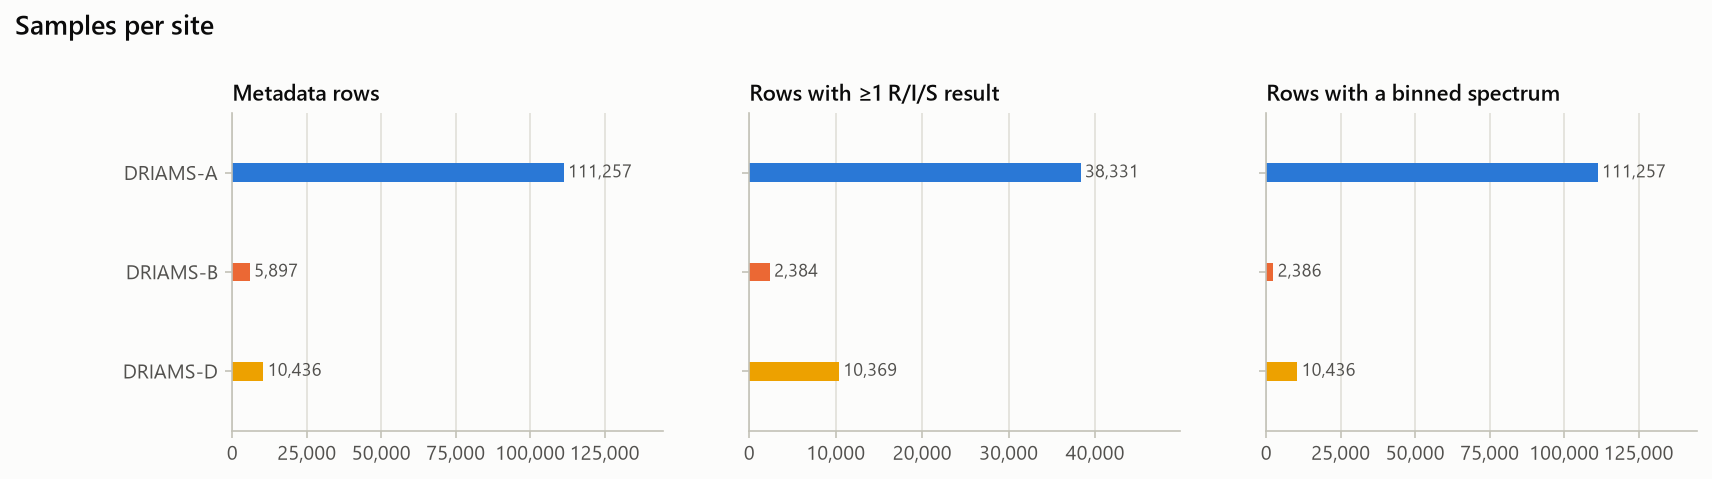

02_samples_per_site_year.png


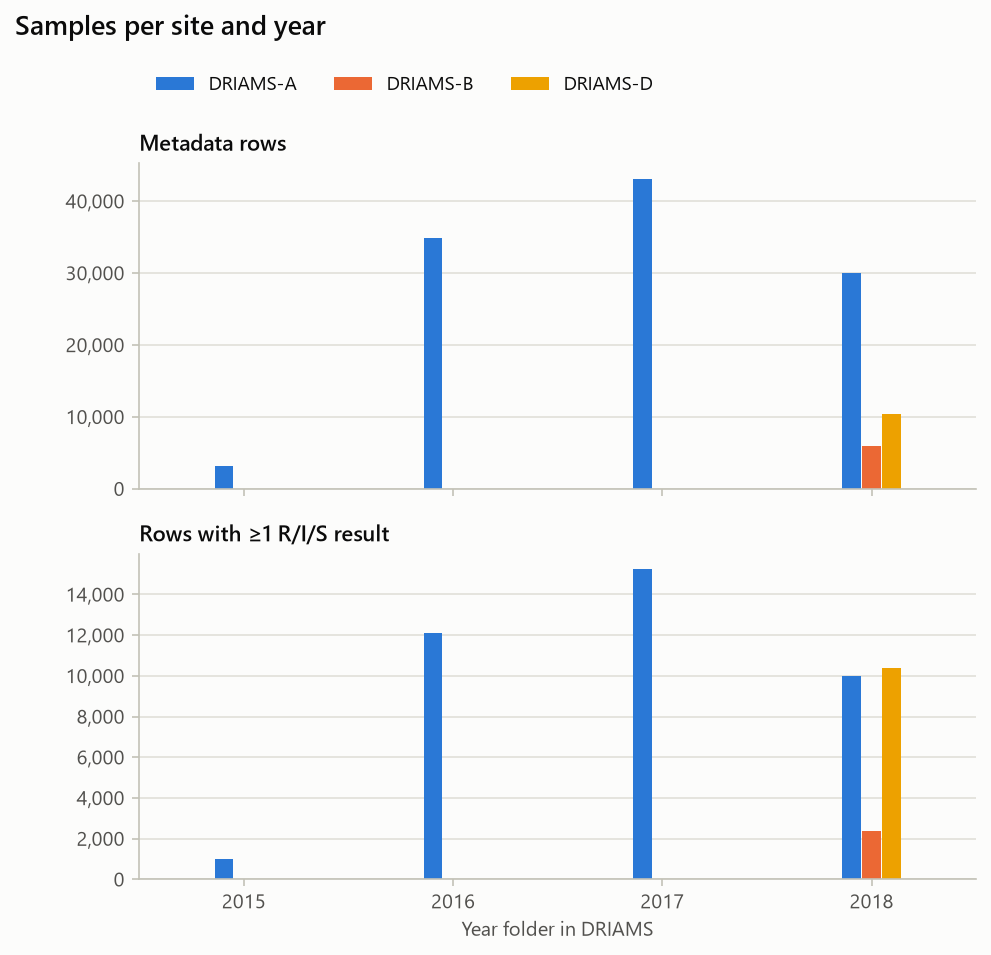

03_acquisitions_per_month.png


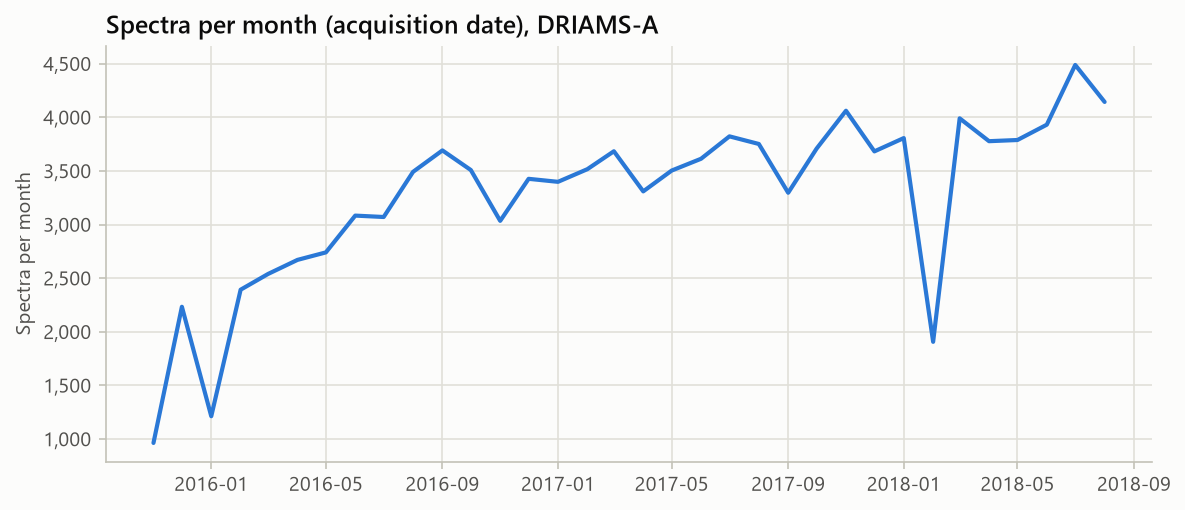

04_top_species.png


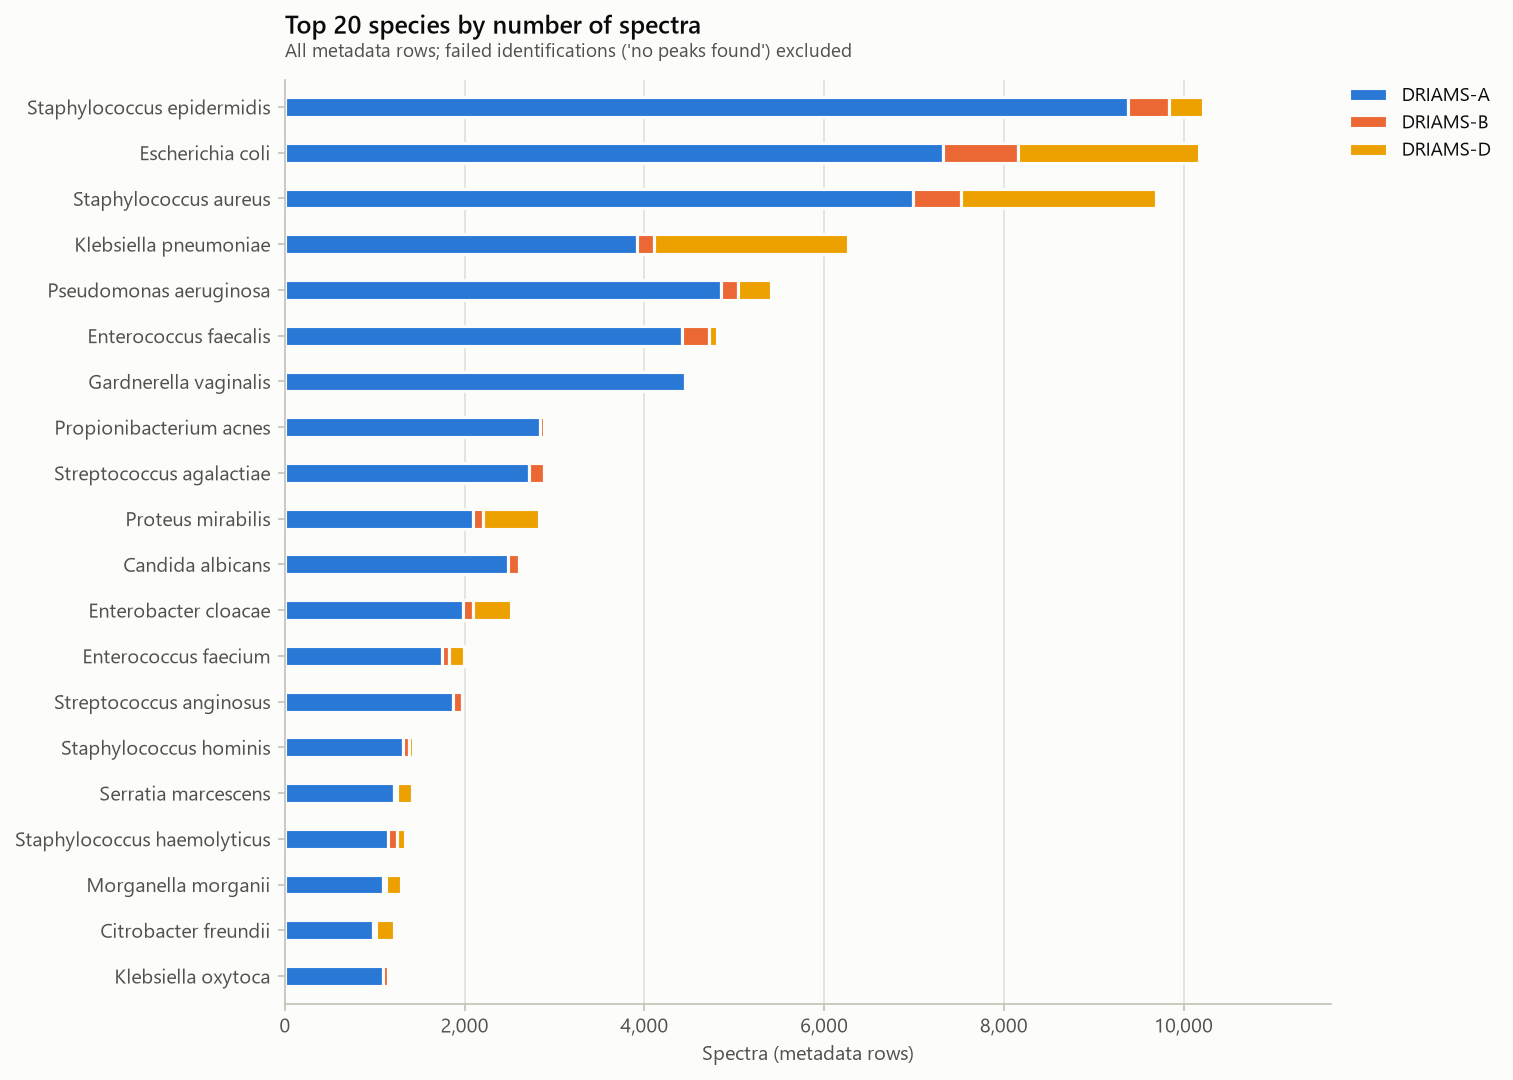

05_top_antibiotics.png


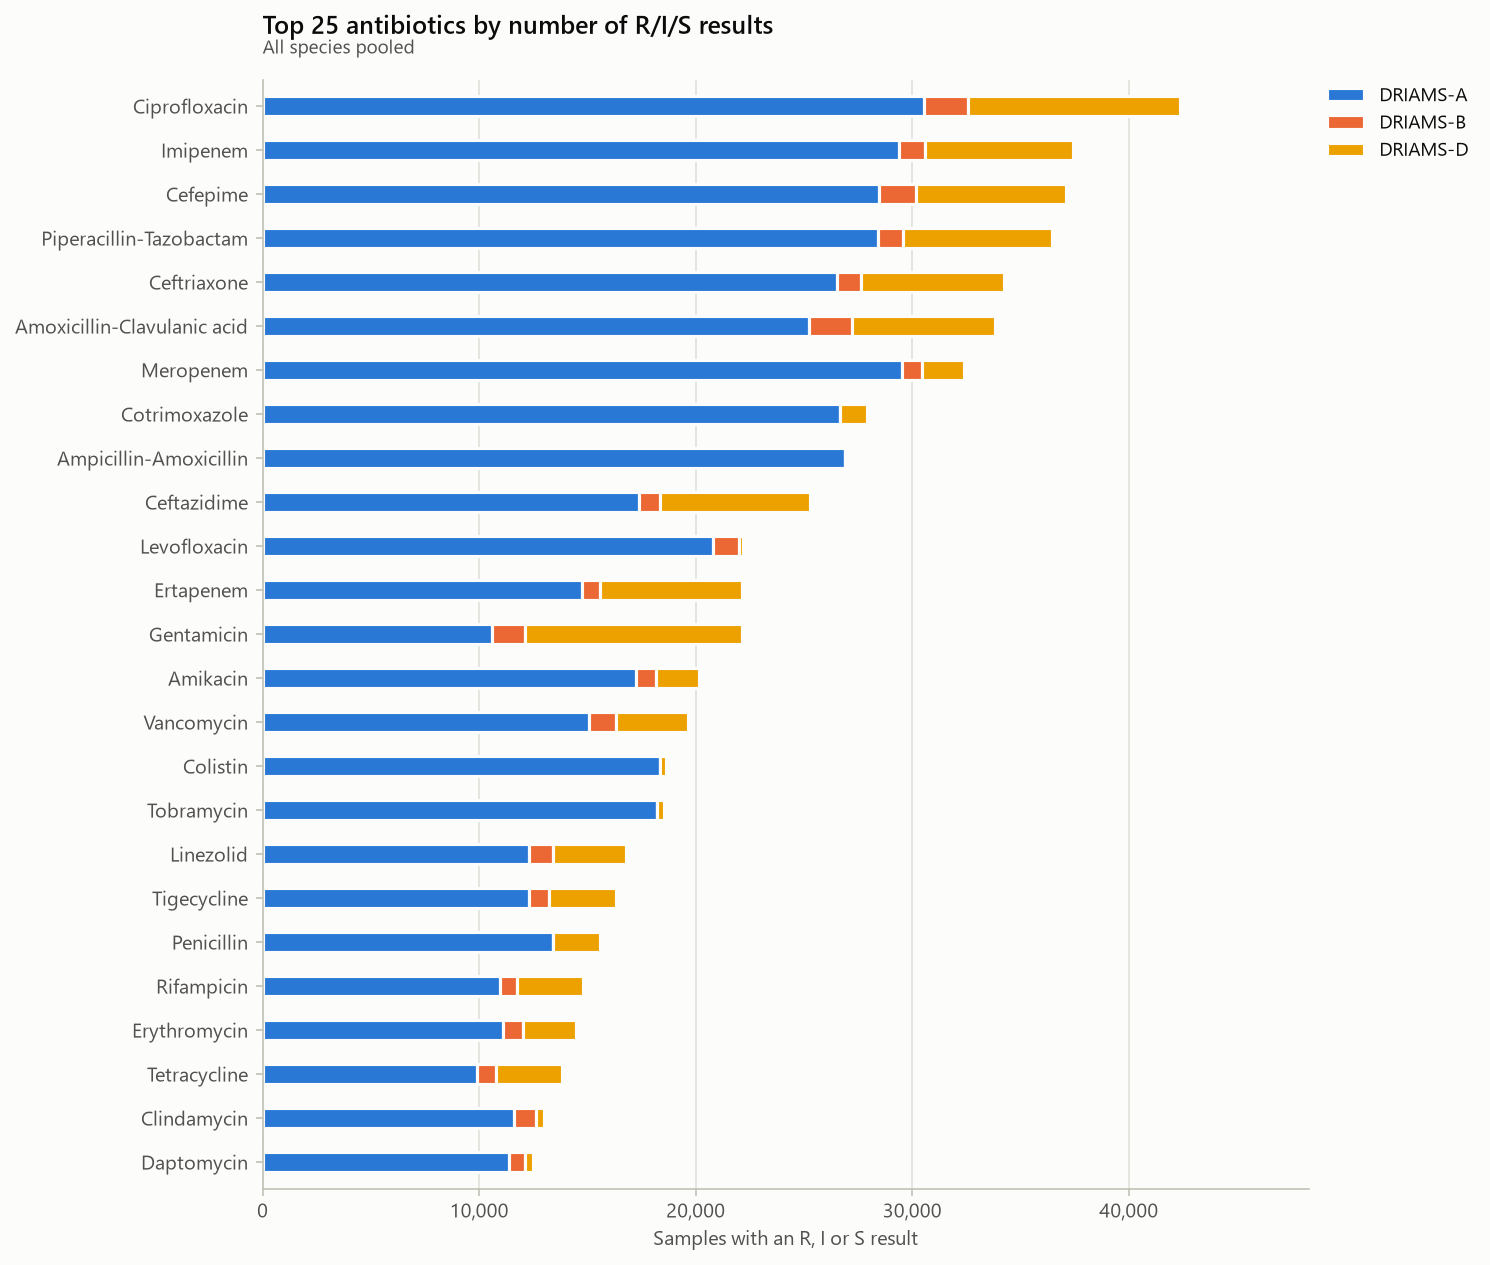

06_label_distribution_all_species.png


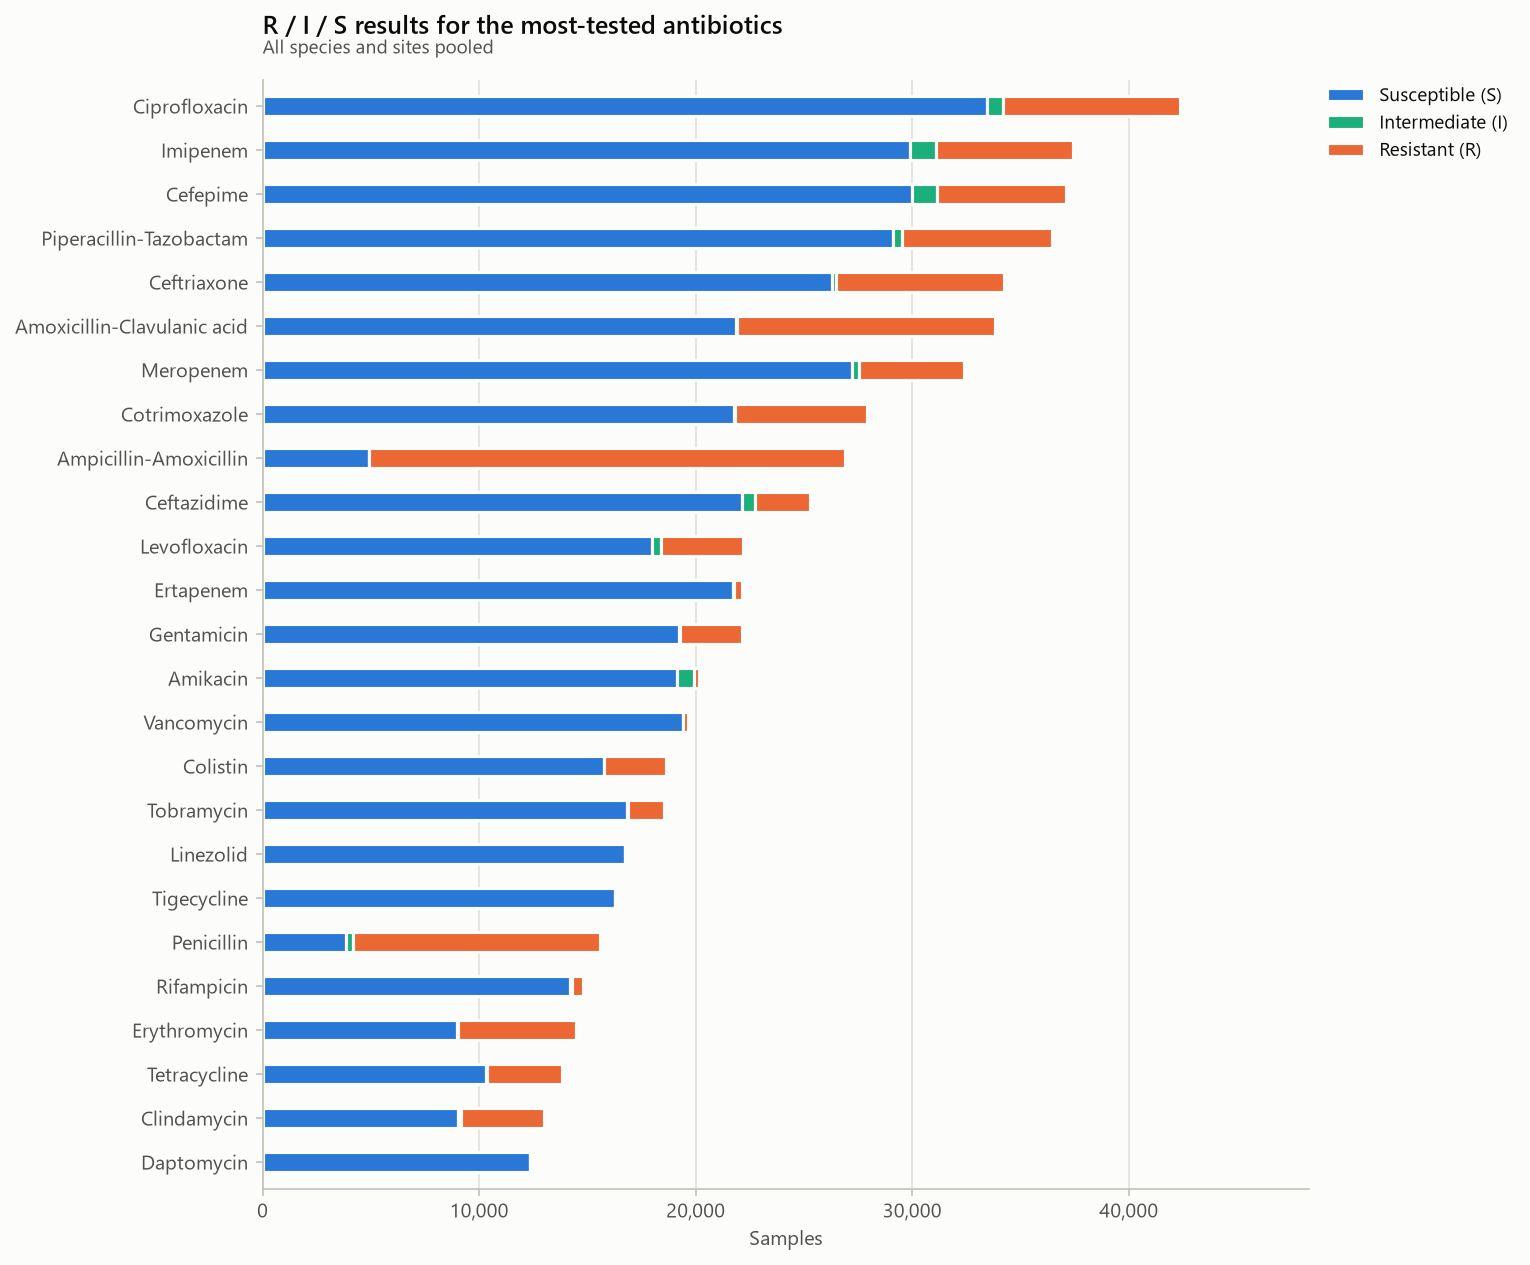

07_target_species_class_balance.png


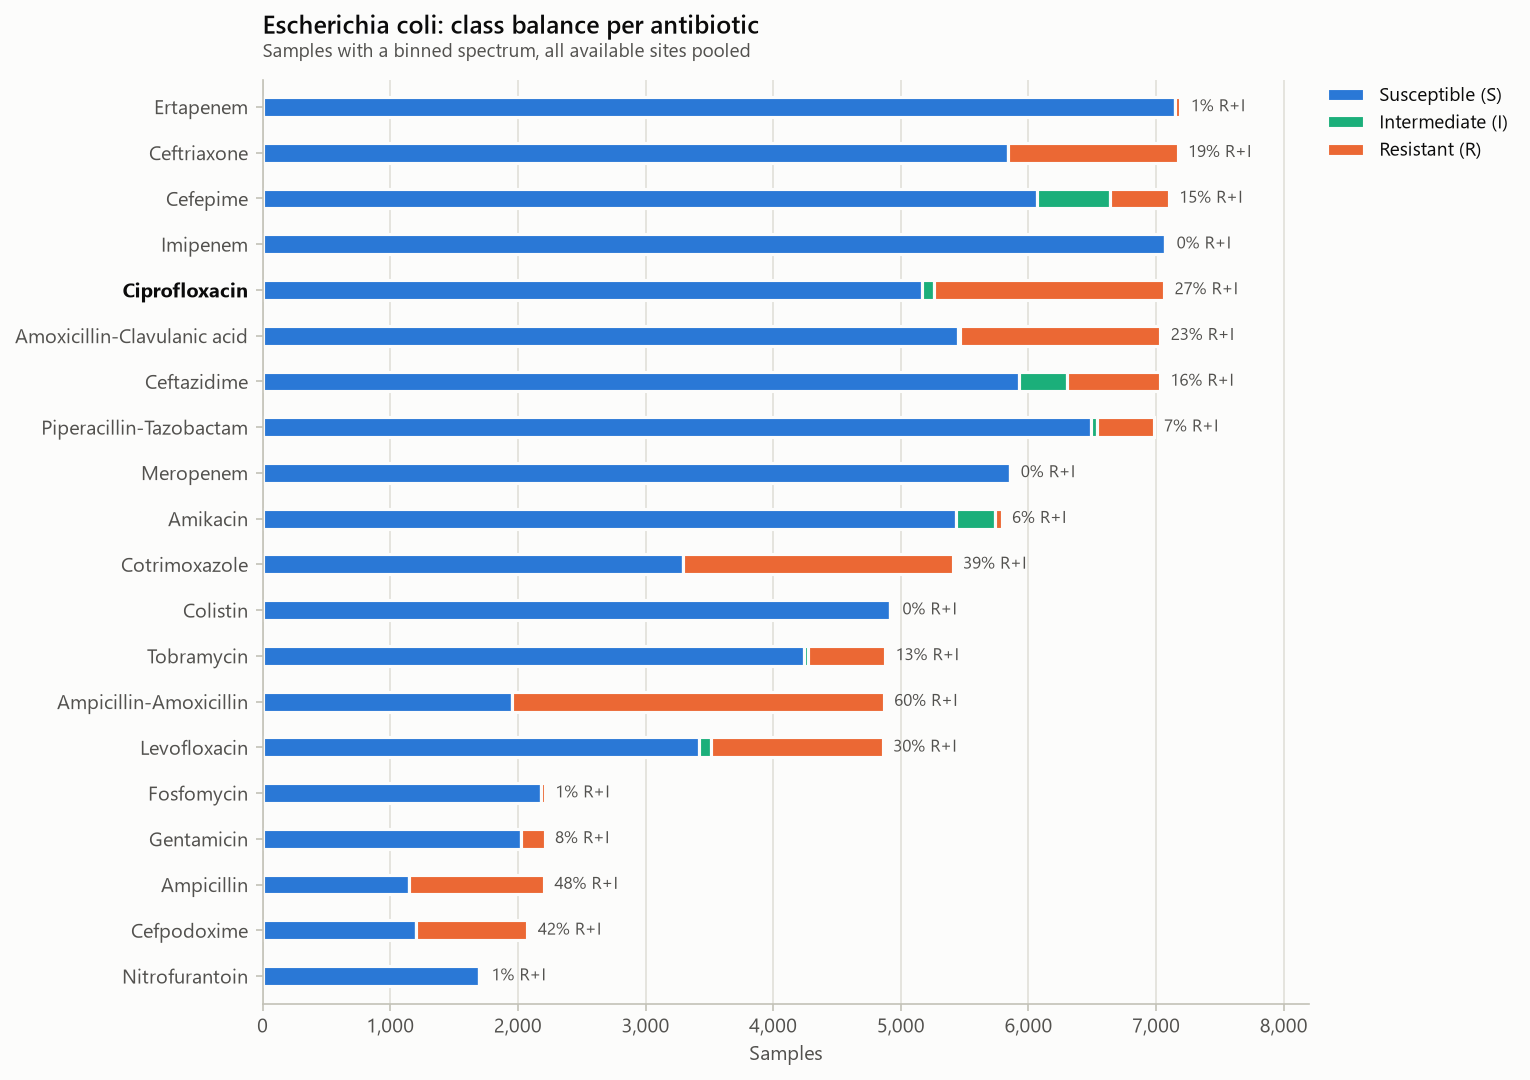

08_focus_pair_by_site_year.png


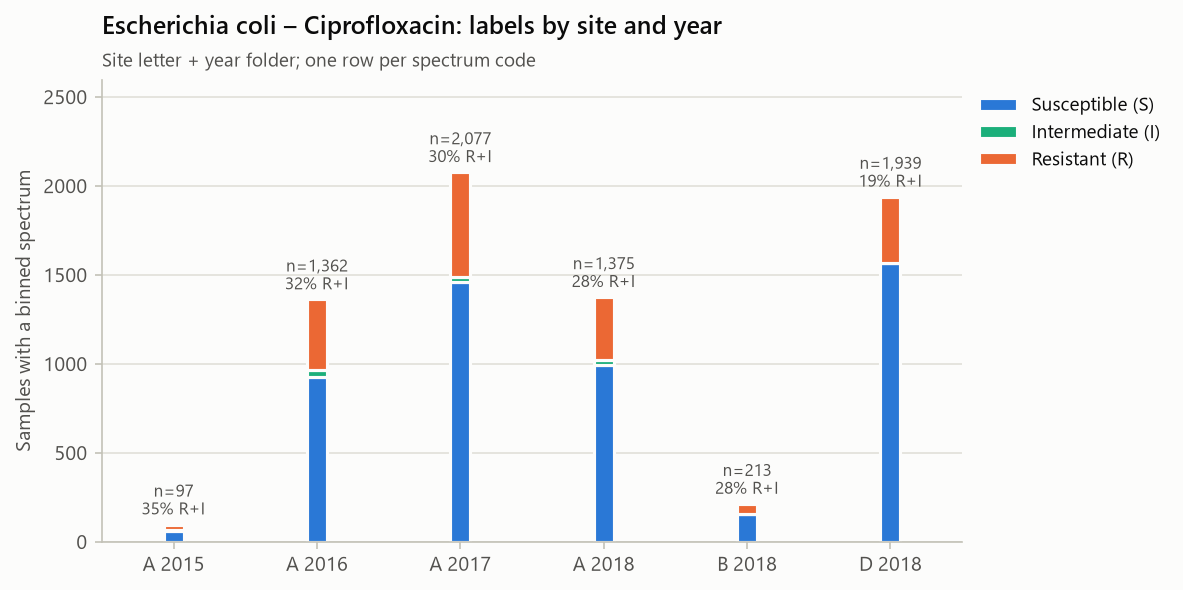

08b_benchmark_pair_by_site_year.png


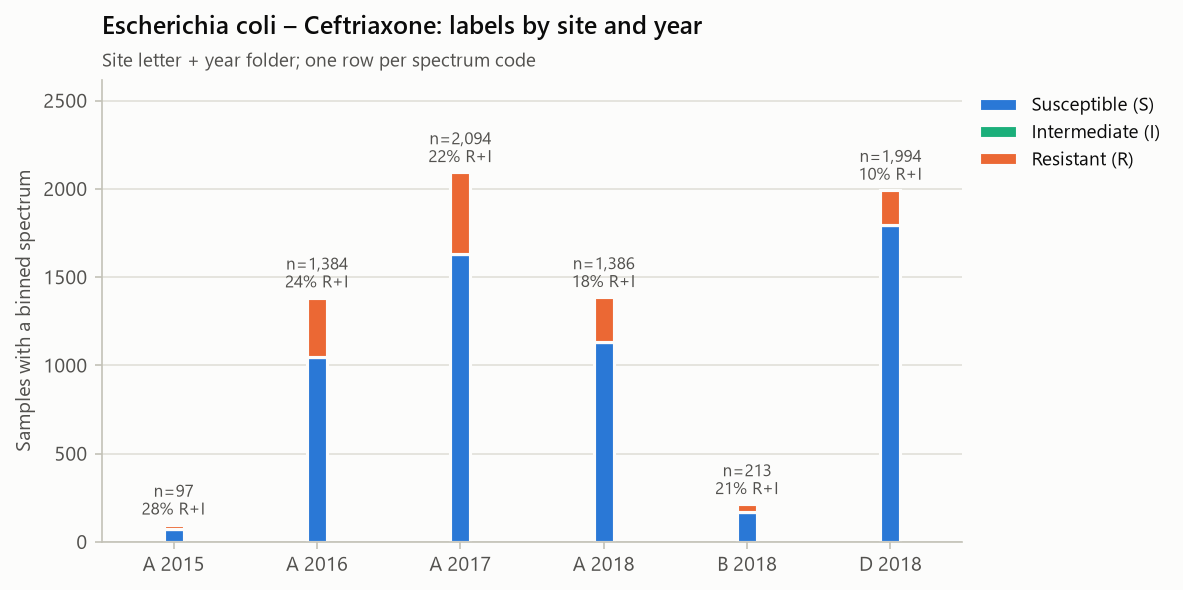

09_target_species_label_coverage.png


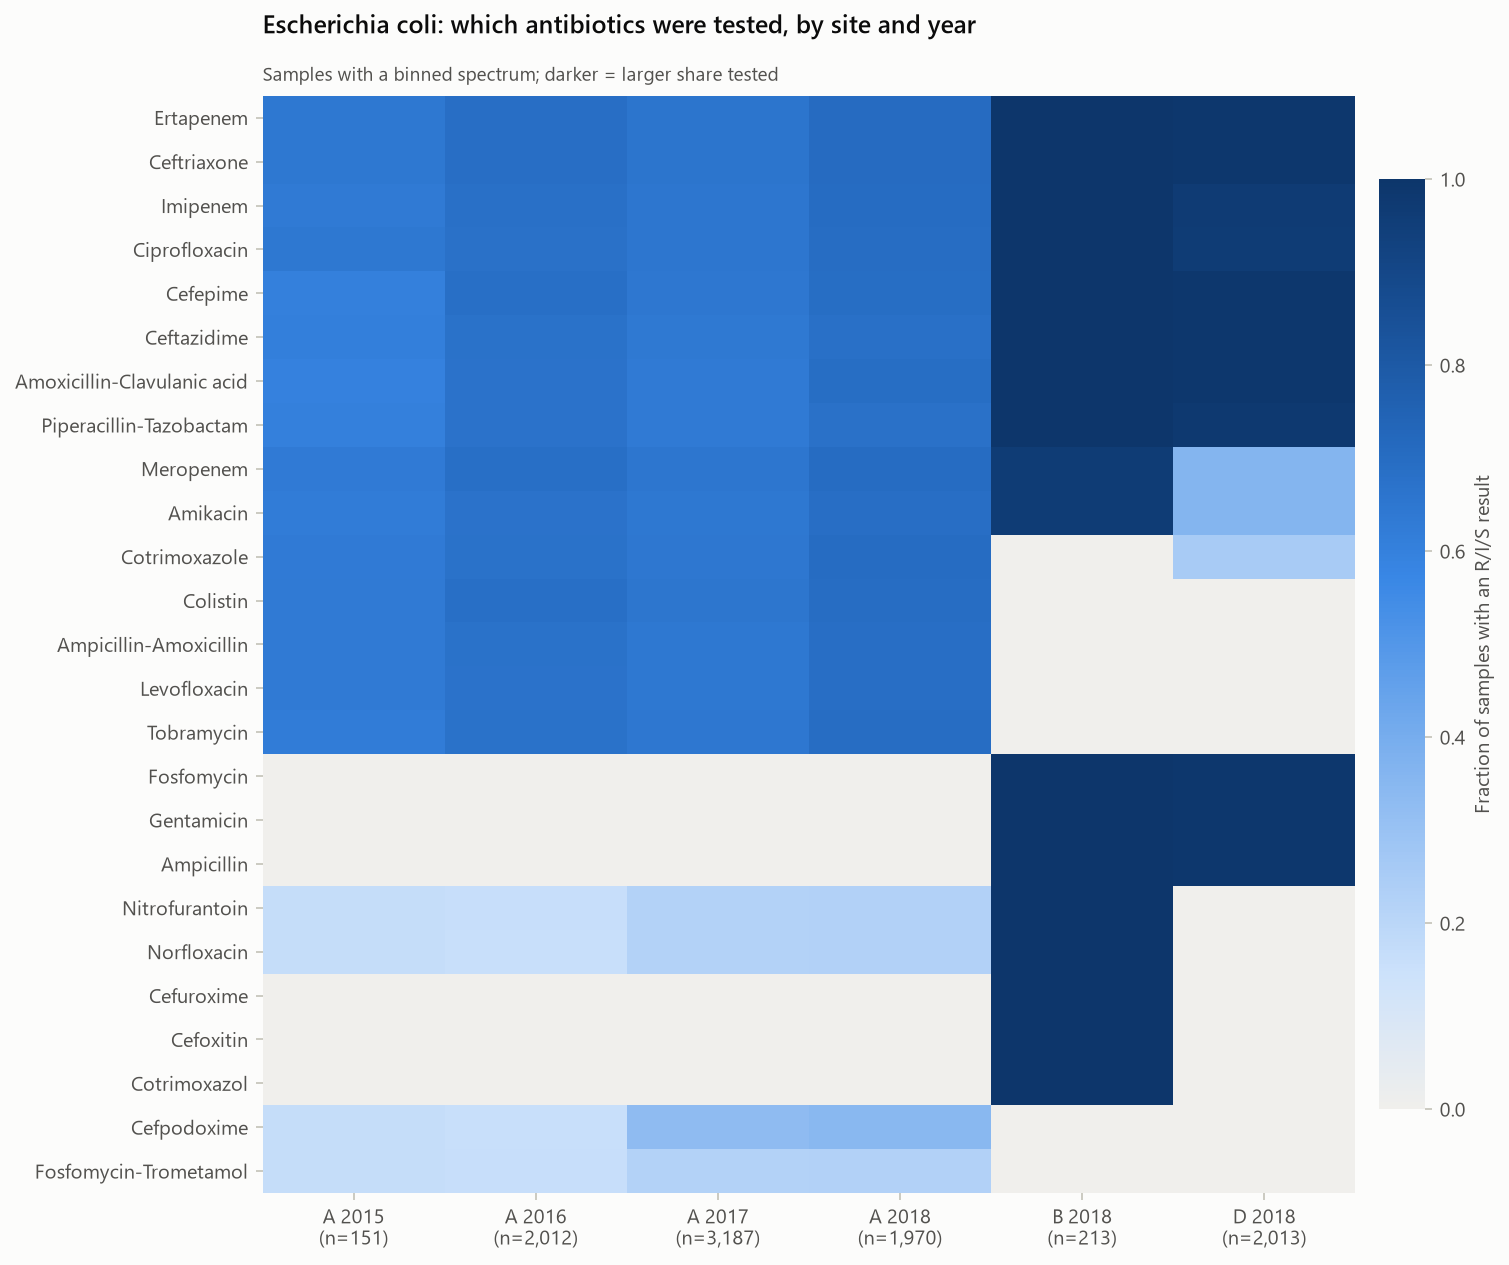

10_example_spectrum.png


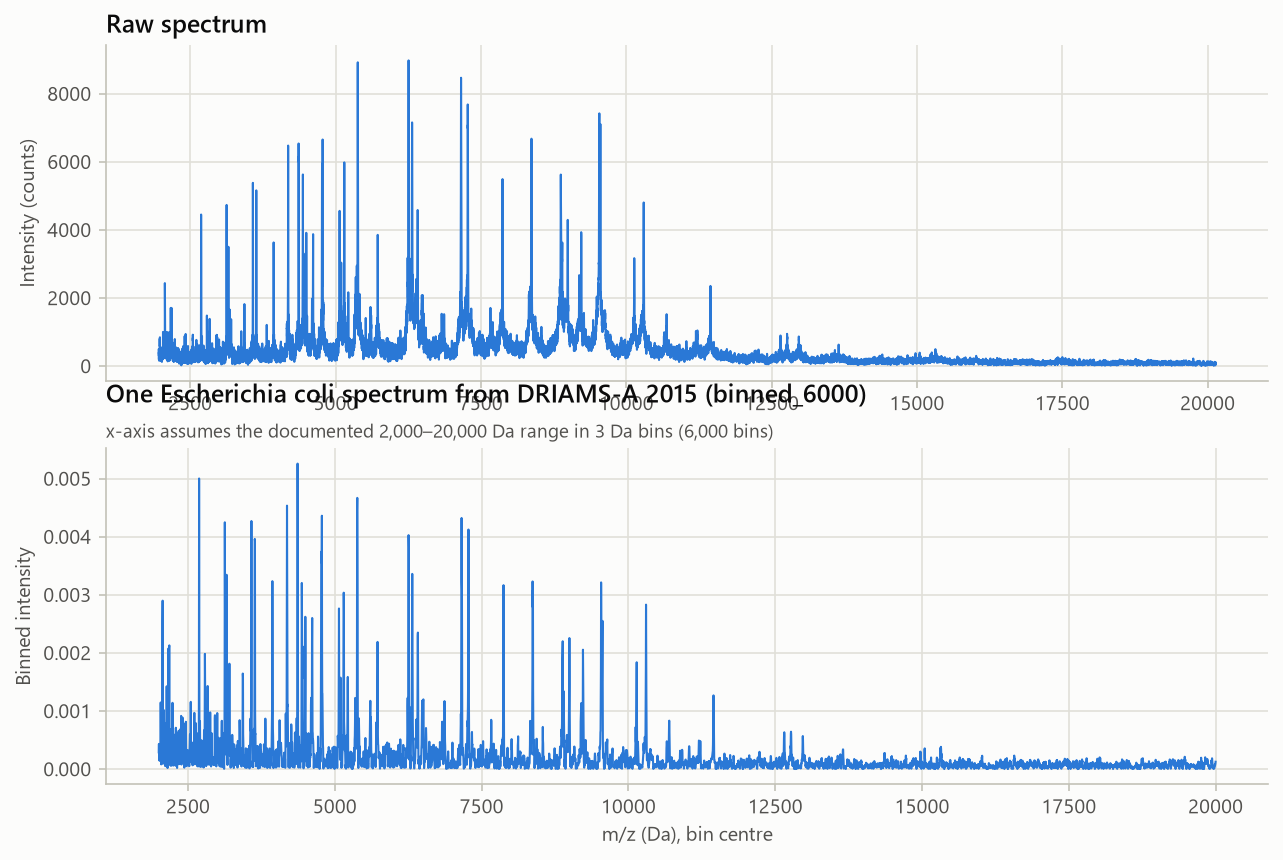

In [8]:
figures = sorted(PLOTS.glob("*.png"))
if not figures:
    print("No figures yet - run: python scripts/explore_dataset.py")
for path in figures:
    print(path.name)
    display(Image(filename=str(path), width=900))